In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
users = pd.read_csv("../Data/users.csv")
activities = pd.read_csv("../Data/activities.csv")
campaigns = pd.read_csv("../Data/campaigns.csv")
user_campaigns = pd.read_csv("../Data/user_campaigns.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
print("Users:", users.shape)
print("Activities:", activities.shape)
print("Campaigns:", campaigns.shape)
print("User Campaigns:", user_campaigns.shape)

Users: (5000, 5)
Activities: (50000, 5)
Campaigns: (12, 5)
User Campaigns: (5000, 2)


In [4]:
users.head()

,user_id,join_date,source,country,wallet_connected
0,U0001,2025-10-16,Discord Invite,UK,Yes
1,U0002,2024-04-24,Ambassador Program,Nigeria,Yes
2,U0003,2024-01-26,Event,Brazil,No
3,U0004,2024-10-08,Referral,UK,No
4,U0005,2024-09-07,Twitter,Canada,Yes


In [5]:
activities.head()

,activity_id,user_id,activity_date,activity_type,points_earned
0,A00001,U1446,2025-11-26,Quest Complete,37
1,A00002,U2065,2025-11-04,Message,32
2,A00003,U4711,2025-08-18,Event Join,8
3,A00004,U3983,2024-08-12,Message,7
4,A00005,U4493,2026-03-11,Quest Complete,3


In [6]:
campaigns.head()

,campaign_id,campaign_name,start_date,spend_usd,end_date
0,C001,Twitter Growth Campaign,2024-01-01,2377,2024-01-30
1,C002,Airdrop Campaign,2024-02-01,4480,2024-03-01
2,C003,Community Quest Program,2024-03-01,2010,2024-03-30
3,C004,Referral Drive,2024-04-01,8756,2024-04-30
4,C005,Ambassador Recruitment,2024-05-01,2577,2024-05-30


In [7]:
user_campaigns.head()

,user_id,campaign_id
0,U1240,C005
1,U2551,C008
2,U3372,C004
3,U4130,C008
4,U1559,C010


In [8]:
print("Users Missing Values")
print(users.isnull().sum())

print("\nActivities Missing Values")
print(activities.isnull().sum())

print("\nCampaigns Missing Values")
print(campaigns.isnull().sum())

print("\nUser Campaigns Missing Values")
print(user_campaigns.isnull().sum())

Users Missing Values
user_id             0
join_date           0
source              0
country             0
wallet_connected    0
dtype: int64

Activities Missing Values
activity_id      0
user_id          0
activity_date    0
activity_type    0
points_earned    0
dtype: int64

Campaigns Missing Values
campaign_id      0
campaign_name    0
start_date       0
spend_usd        0
end_date         0
dtype: int64

User Campaigns Missing Values
user_id        0
campaign_id    0
dtype: int64


In [9]:
print("Users:", users.duplicated().sum())
print("Activities:", activities.duplicated().sum())
print("Campaigns:", campaigns.duplicated().sum())
print("User Campaigns:", user_campaigns.duplicated().sum())

Users: 0
Activities: 0
Campaigns: 0
User Campaigns: 0


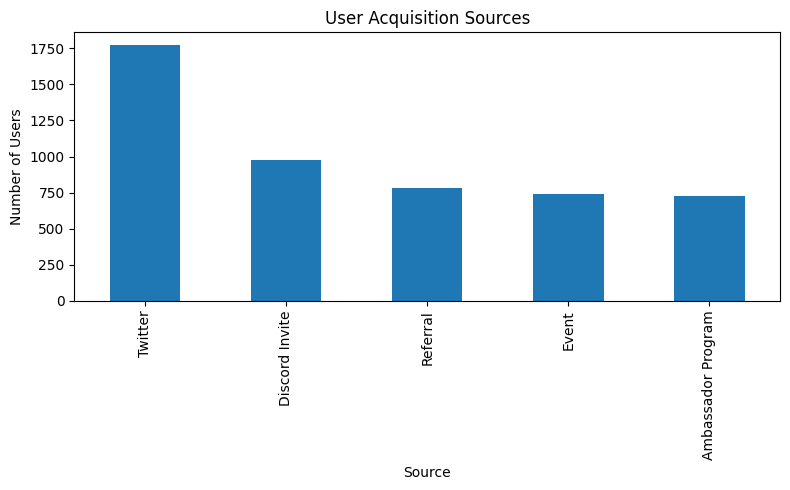

In [10]:
source_counts = users['source'].value_counts()

source_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('User Acquisition Sources')
plt.xlabel('Source')
plt.ylabel('Number of Users')
plt.tight_layout()

plt.show()

In [11]:
source_counts

source
Twitter               1771
Discord Invite         977
Referral               782
Event                  740
Ambassador Program     730
Name: count, dtype: int64

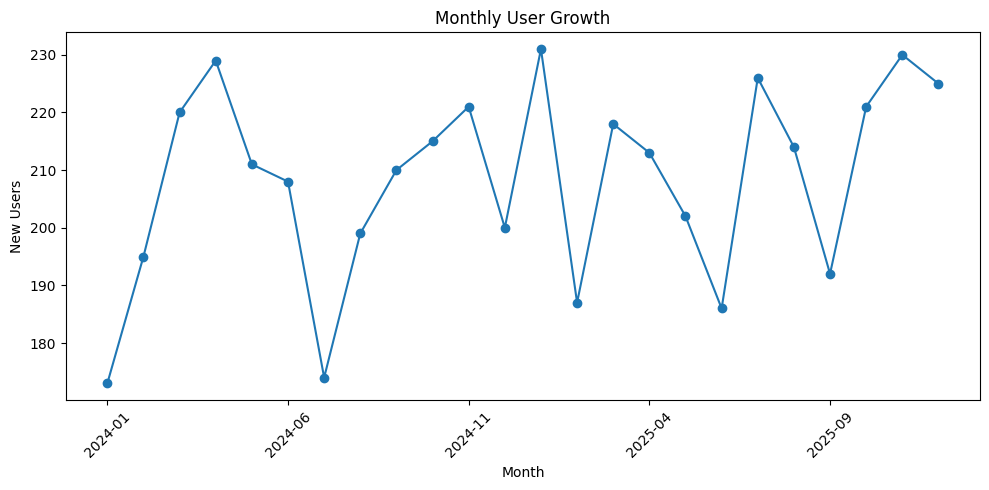

In [12]:
users['join_date'] = pd.to_datetime(users['join_date'])

monthly_users = (
    users.groupby(users['join_date'].dt.to_period('M'))
    .size()
)

monthly_users.index = monthly_users.index.astype(str)

monthly_users.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)

plt.title('Monthly User Growth')
plt.xlabel('Month')
plt.ylabel('New Users')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
monthly_users

join_date
2024-01    173
2024-02    195
2024-03    220
2024-04    229
2024-05    211
2024-06    208
2024-07    174
2024-08    199
2024-09    210
2024-10    215
2024-11    221
2024-12    200
2025-01    231
2025-02    187
2025-03    218
2025-04    213
2025-05    202
2025-06    186
2025-07    226
2025-08    214
2025-09    192
2025-10    221
2025-11    230
2025-12    225
dtype: int64

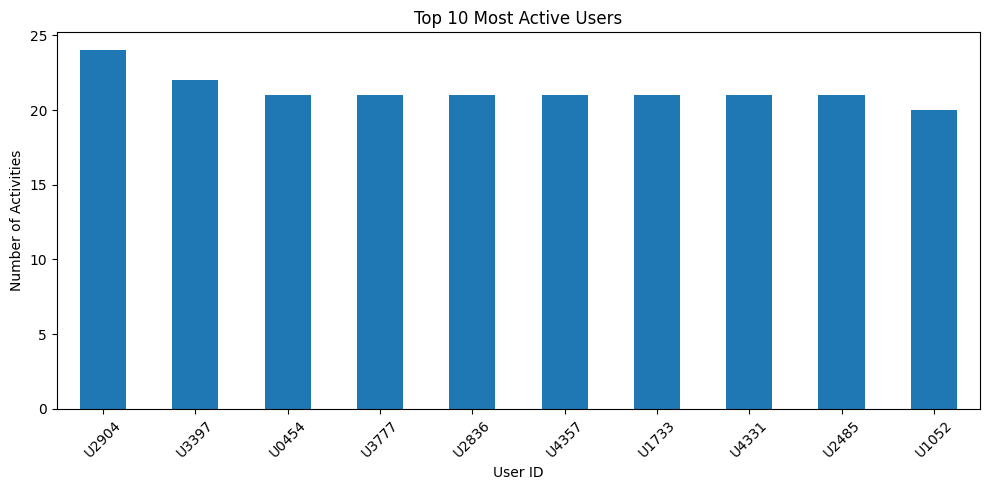

In [14]:
top_users = activities['user_id'].value_counts().head(10)

top_users.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Activities')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
top_users

user_id
U2904    24
U3397    22
U0454    21
U3777    21
U2836    21
U4357    21
U1733    21
U4331    21
U2485    21
U1052    20
Name: count, dtype: int64

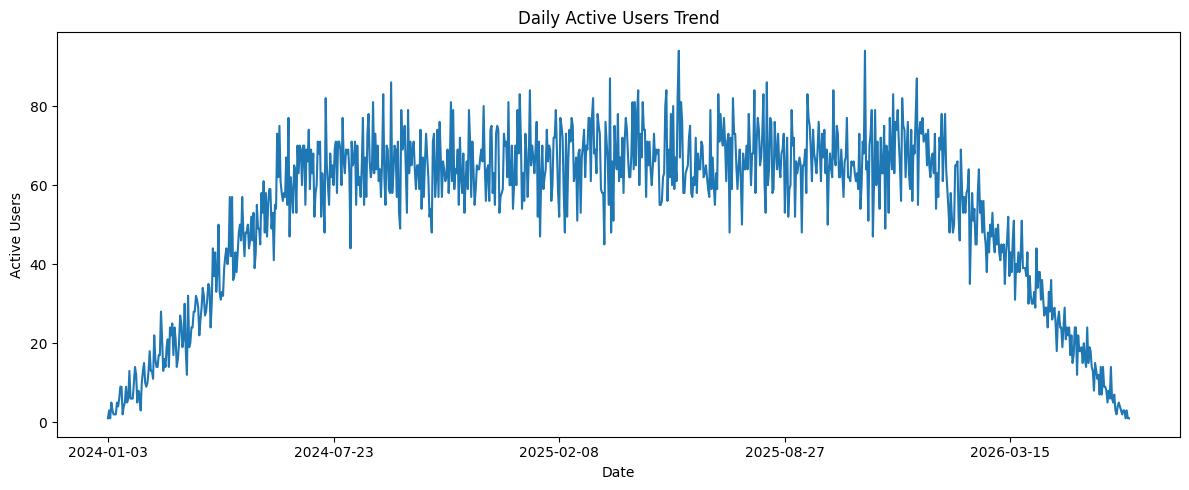

In [16]:
daily_active = (
    activities.groupby('activity_date')['user_id']
    .nunique()
)

plt.figure(figsize=(12,5))
daily_active.plot()

plt.title('Daily Active Users Trend')
plt.xlabel('Date')
plt.ylabel('Active Users')
plt.tight_layout()

plt.show()

In [17]:
daily_active.describe()

count    906.000000
mean      53.713024
std       21.255753
min        1.000000
25%       43.250000
50%       60.000000
75%       69.000000
max       94.000000
Name: user_id, dtype: float64

In [19]:
activities['activity_date'] = pd.to_datetime(activities['activity_date'])

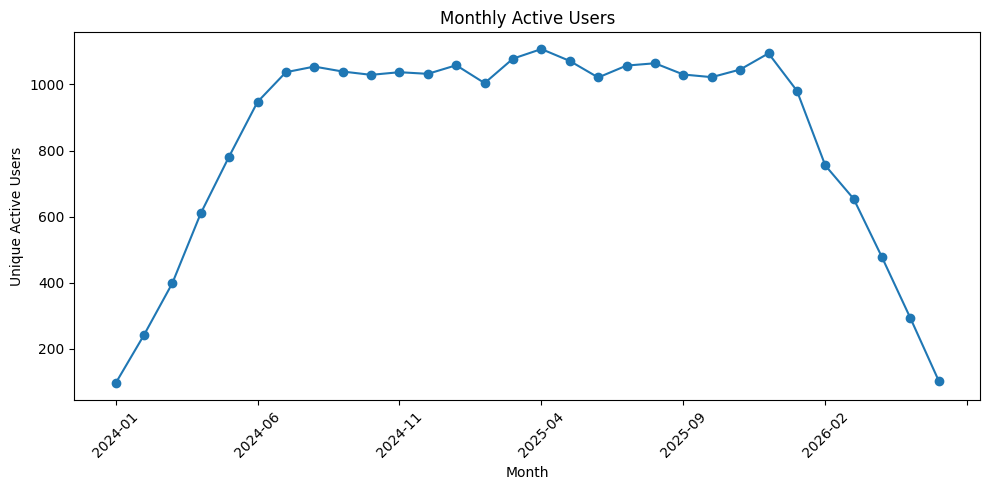

In [20]:
monthly_active = (
    activities.groupby(
        activities['activity_date'].dt.to_period('M')
    )['user_id']
    .nunique()
)

monthly_active.index = monthly_active.index.astype(str)

plt.figure(figsize=(10,5))
monthly_active.plot(marker='o')

plt.title('Monthly Active Users')
plt.xlabel('Month')
plt.ylabel('Unique Active Users')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
monthly_active

activity_date
2024-01      96
2024-02     242
2024-03     399
2024-04     610
2024-05     782
2024-06     947
2024-07    1037
2024-08    1054
2024-09    1039
2024-10    1029
2024-11    1037
2024-12    1032
2025-01    1058
2025-02    1004
2025-03    1078
2025-04    1107
2025-05    1071
2025-06    1021
2025-07    1057
2025-08    1064
2025-09    1030
2025-10    1022
2025-11    1045
2025-12    1094
2026-01     981
2026-02     755
2026-03     654
2026-04     477
2026-05     293
2026-06     103
Name: user_id, dtype: int64

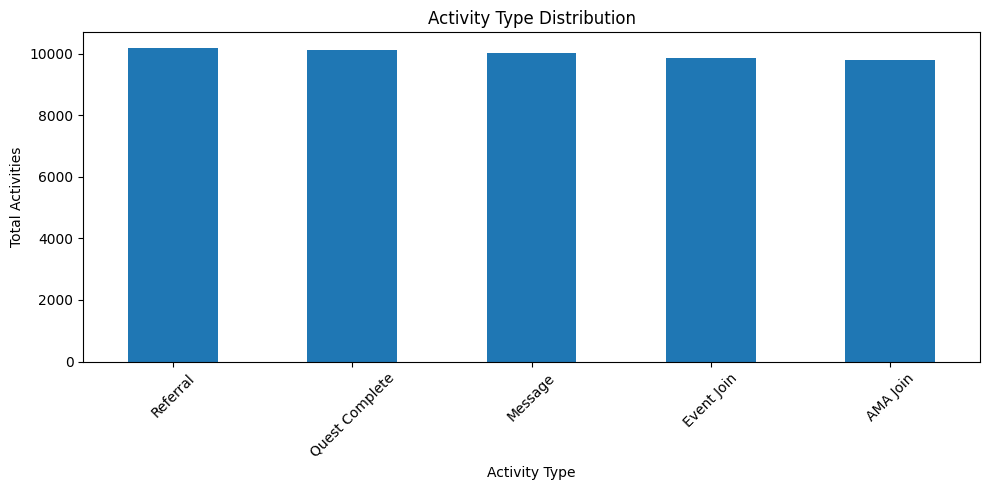

In [22]:
activity_counts = activities['activity_type'].value_counts()

activity_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Activity Type Distribution')
plt.xlabel('Activity Type')
plt.ylabel('Total Activities')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
activity_counts

activity_type
Referral          10187
Quest Complete    10124
Message           10014
Event Join         9863
AMA Join           9812
Name: count, dtype: int64

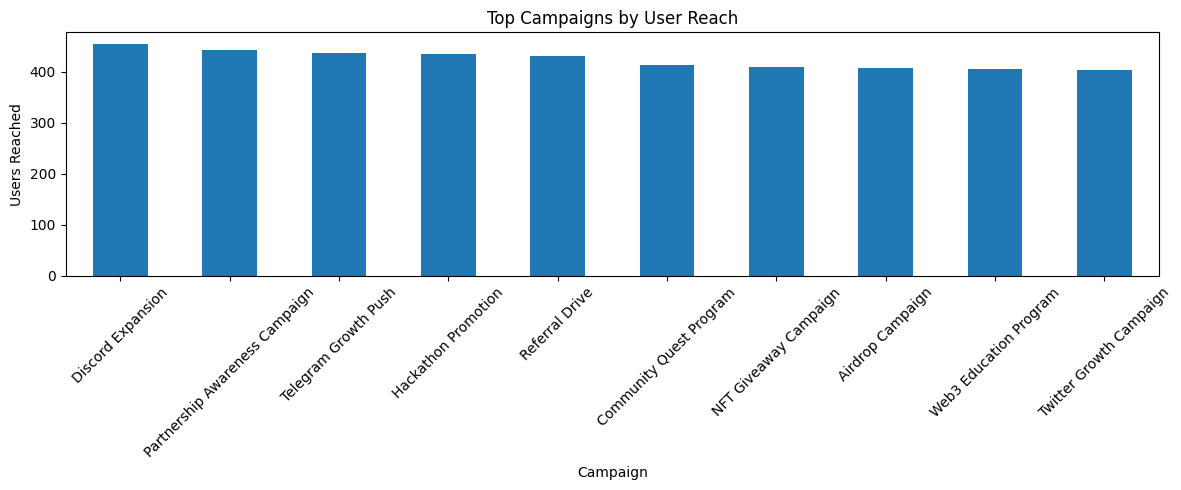

In [24]:
campaign_reach = (
    user_campaigns.groupby('campaign_id')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

campaign_reach = campaign_reach.reset_index()

campaign_reach = campaign_reach.merge(
    campaigns[['campaign_id','campaign_name']],
    on='campaign_id'
)

campaign_reach = campaign_reach.sort_values(
    by='user_id',
    ascending=False
)

campaign_reach.head(10).plot(
    x='campaign_name',
    y='user_id',
    kind='bar',
    figsize=(12,5),
    legend=False
)

plt.title('Top Campaigns by User Reach')
plt.xlabel('Campaign')
plt.ylabel('Users Reached')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
campaign_reach.head(10)

,campaign_id,user_id,campaign_name
0,C006,454,Discord Expansion
1,C012,442,Partnership Awareness Campaign
2,C007,437,Telegram Growth Push
3,C011,435,Hackathon Promotion
4,C004,430,Referral Drive
5,C003,413,Community Quest Program
6,C008,408,NFT Giveaway Campaign
7,C002,406,Airdrop Campaign
8,C010,405,Web3 Education Program
9,C001,403,Twitter Growth Campaign


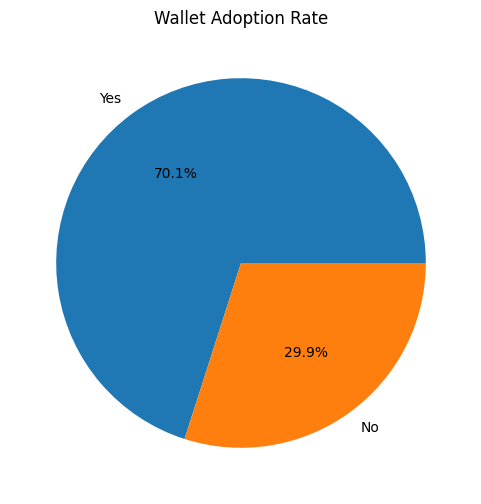

In [26]:
wallet_adoption = (
    users['wallet_connected']
    .value_counts()
)

wallet_adoption.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Wallet Adoption Rate')
plt.ylabel('')

plt.show()

In [27]:
wallet_adoption

wallet_connected
Yes    3503
No     1497
Name: count, dtype: int64

In [28]:
user_activity = (
    activities.groupby('user_id')
    .agg(
        total_activities=('activity_id', 'count'),
        avg_points=('points_earned', 'mean')
    )
)

user_wallet = users.copy()

user_wallet['wallet_flag'] = (
    user_wallet['wallet_connected']
    .map({'Yes':1, 'No':0})
)

analysis_df = user_activity.merge(
    user_wallet[['user_id','wallet_flag']],
    on='user_id'
)

analysis_df.head()

,user_id,total_activities,avg_points,wallet_flag
0,U0001,5,37.000000,1
1,U0002,9,25.222222,1
2,U0003,11,22.272727,0
3,U0004,12,25.083333,0
4,U0005,17,23.823529,1


In [30]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import seaborn as sns

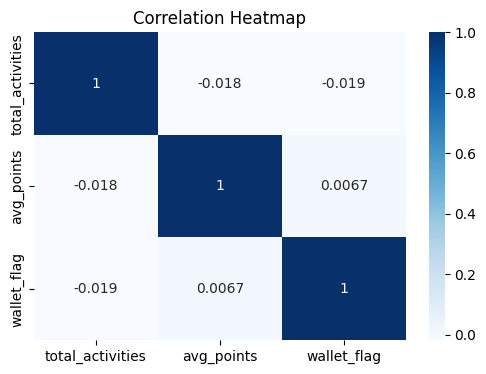

In [32]:
import seaborn as sns

corr = analysis_df[
    ['total_activities','avg_points','wallet_flag']
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()